In [ ]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")
    
    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "Entornos_Complejos"))
    
    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "Entornos_Complejos", "src"))
    
    # Instalar dependencias
    !pip install gymnasium flappy-bird-gymnasium gym-simplegrid "gymnasium[other]" numpy pandas matplotlib torch tqdm
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import flappy_bird_gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import os
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import sys


from src.utils import * # type: ignore
from src.agent import Agent # type: ignore
from src.DQN_Network import DQN_Network # type: ignore
from src.DQNAgent import DQNAgent # type: ignore
from src.SARSASemiGradientAgent import SARSASemiGradientAgent # type: ignore
from src.plotting import * # type: ignore

ENV = "FlappyBird-v0"
EPISODES = 10000

# Configurazione per la riproducibilità 
seed = 2024
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

sys.path.append(os.path.abspath('src'))

# Configuración de estilo para las gráficas
plt.style.use('default')

# setting device
if torch.cuda.is_available(): device = torch.device("cuda")         
elif torch.backends.mps.is_available(): device = torch.device("mps")         
else:  device = torch.device("cpu")        

if torch.cuda.is_available():
    set_global_seed(2024, device)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(2024)
make_env_with_seed(ENV, seed)

print("Using device:", device)
print(f"Ejecución en: {device}")


Configurando semilla global (Global Seed): 2024
GPU no detectada. Usando CPU.
Using device: mps
Esecuzione su: mps


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


### Configuración del experimento

El entorno `FlappyBird-v0` presenta un espacio de estados continuo y de alta dimensionalidad, incompatible con representaciones tabulares. Se utilizaron redes neuronales como aproximadores de la función de valor Q.

- **DQN:** red neuronal con Experience Replay y Target Network separada
- **SARSA Semi-Gradient:** red neuronal entrenada on-policy sin replay buffer
- **Episodios:** 10.000 para todos los experimentos
- **Epsilon decay:** lineal de 1.0 a 0.01 en el 90% del training

In [ ]:
def run_experiment(agent_class, env_name, episodes=EPISODES, **kwargs):
    env = gym.make(env_name, render_mode="rgb_array")
    env.action_space.seed(2024)
    agent = agent_class(env, **kwargs)
    rewards_per_episode = []
    
    # Parámetros para la caducidad manual
    eps = 1.0          # Comienza en 1.0 (exploración total)
    eps_min = 0.01     # Llega a 0,01 (precisión máxima)
    # Decadencia: cada episodio va perdiendo intensidad
    eps_decay = (eps - eps_min) / (episodes * 0.9) 
    current_eps = eps

    for ep in tqdm(range(episodes), desc=f"Training {agent_class.__name__}"):
        obs, _ = env.reset(seed=seed)
        done = False
        total_reward = 0
        
        agent.epsilon = current_eps
        
        action = agent.get_action(obs)
        
        while not done:
            next_obs, reward, terminated, truncated, info = env.step(action)
            
            agent.update(obs, action, next_obs, reward, terminated, truncated, info)
            
            if isinstance(agent, SARSASemiGradientAgent): action = agent.last_next_action
            else: action = agent.get_action(next_obs)
                
            obs = next_obs
            total_reward += reward
            done = terminated or truncated
            
        # Reduce el épsilon después de cada episodio
        # Decaimiento del épsilon
        if current_eps > eps_min: 
            current_eps -= eps_decay
            
        rewards_per_episode.append(total_reward)
        # Registro cada 500 episodios
        if (ep + 1) %2000 == 0:
            avg = np.mean(rewards_per_episode[-100:])
            print(f"Episode {ep+1}/{episodes} | Epsilon: {current_eps:.3f} | Avg last 100: {avg:.2f}")
        
    return rewards_per_episode, agent


In [ ]:
# parameters
params_DQN = {
    'learning_rate': 1e-4,
    'gamma': 0.99, 
    'epsilon': 0.05,
    'batch_size': 128,         
    'target_update_freq':1000,
    'memory_size': 100000
}

params_SARSA = {
    'learning_rate': 1e-4,  
    'gamma': 0.99,
    'epsilon': 0.05
}


n_episodes = [EPISODES]

results = {n: {} for n in n_episodes}
agents = {n: {} for n in n_episodes}

for n in n_episodes:
    print(f"\n--- Running with {n} episodes ---")
    results[n]['SARSA'], agents[n]['SARSA']= run_experiment(SARSASemiGradientAgent, "FlappyBird-v0", episodes=n, **params_SARSA)
    print('\n\n\n')
    results[n]['DQN'], agents[n]['DQN'] = run_experiment(DQNAgent, "FlappyBird-v0", episodes=n, **params_DQN)

    cleanup()


--- Running with 10000 episodes ---


Training SARSASemiGradientAgent:   0%|          | 0/10000 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
Training SARSASemiGradientAgent:   5%|▌         | 501/10000 [01:34<29:38,  5.34it/s]

Episode 500/10000 | Epsilon: 0.945 | Avg last 100: -7.35


Training SARSASemiGradientAgent:  10%|█         | 1001/10000 [03:09<27:46,  5.40it/s]

Episode 1000/10000 | Epsilon: 0.890 | Avg last 100: -7.47


...

Episode 9000/10000 | Epsilon: 0.010 | Avg last 100: 2.93


Training DQNAgent:  95%|█████████▌| 9500/10000 [45:19<02:52,  2.89it/s]

Episode 9500/10000 | Epsilon: 0.010 | Avg last 100: 2.75


Training DQNAgent: 100%|██████████| 10000/10000 [49:05<00:00,  3.40it/s]

Episode 10000/10000 | Epsilon: 0.010 | Avg last 100: 2.55


### Resultados del training

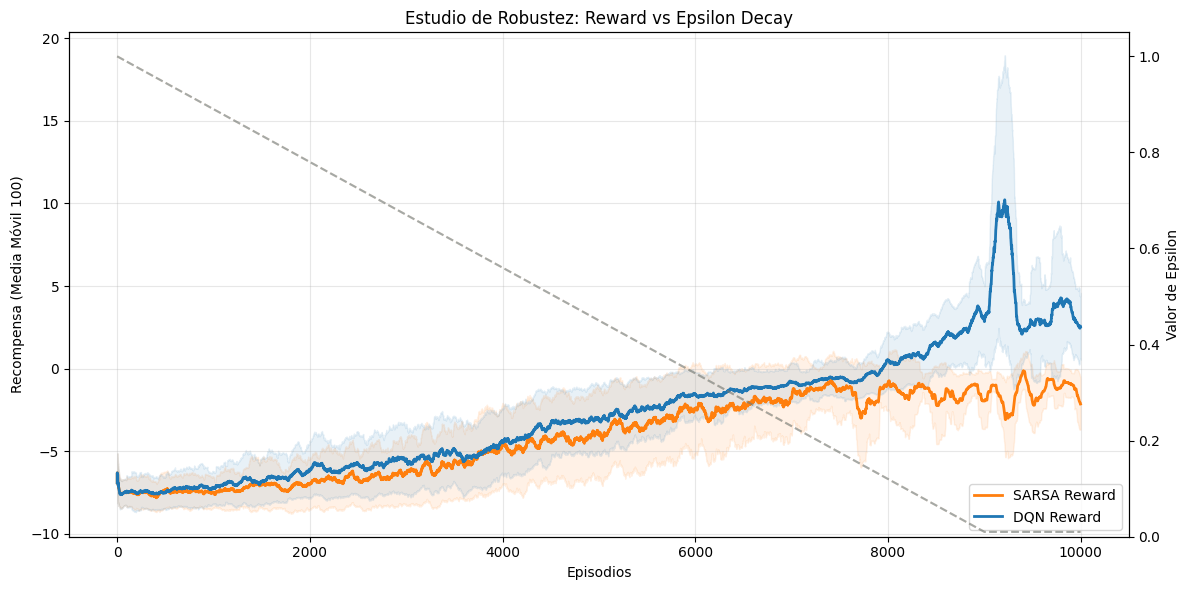

In [ ]:
plot_epsilon_robustness(results[EPISODES])


--- Analysis of results for 10000 episodes --- 

  Algorithm  Best Reward Avg last 100 Stability (Std Dev) Episode Convergence
0     SARSA          4.9        -2.14                1.35         Not reached
1       DQN         27.9         2.55                2.30         Not reached


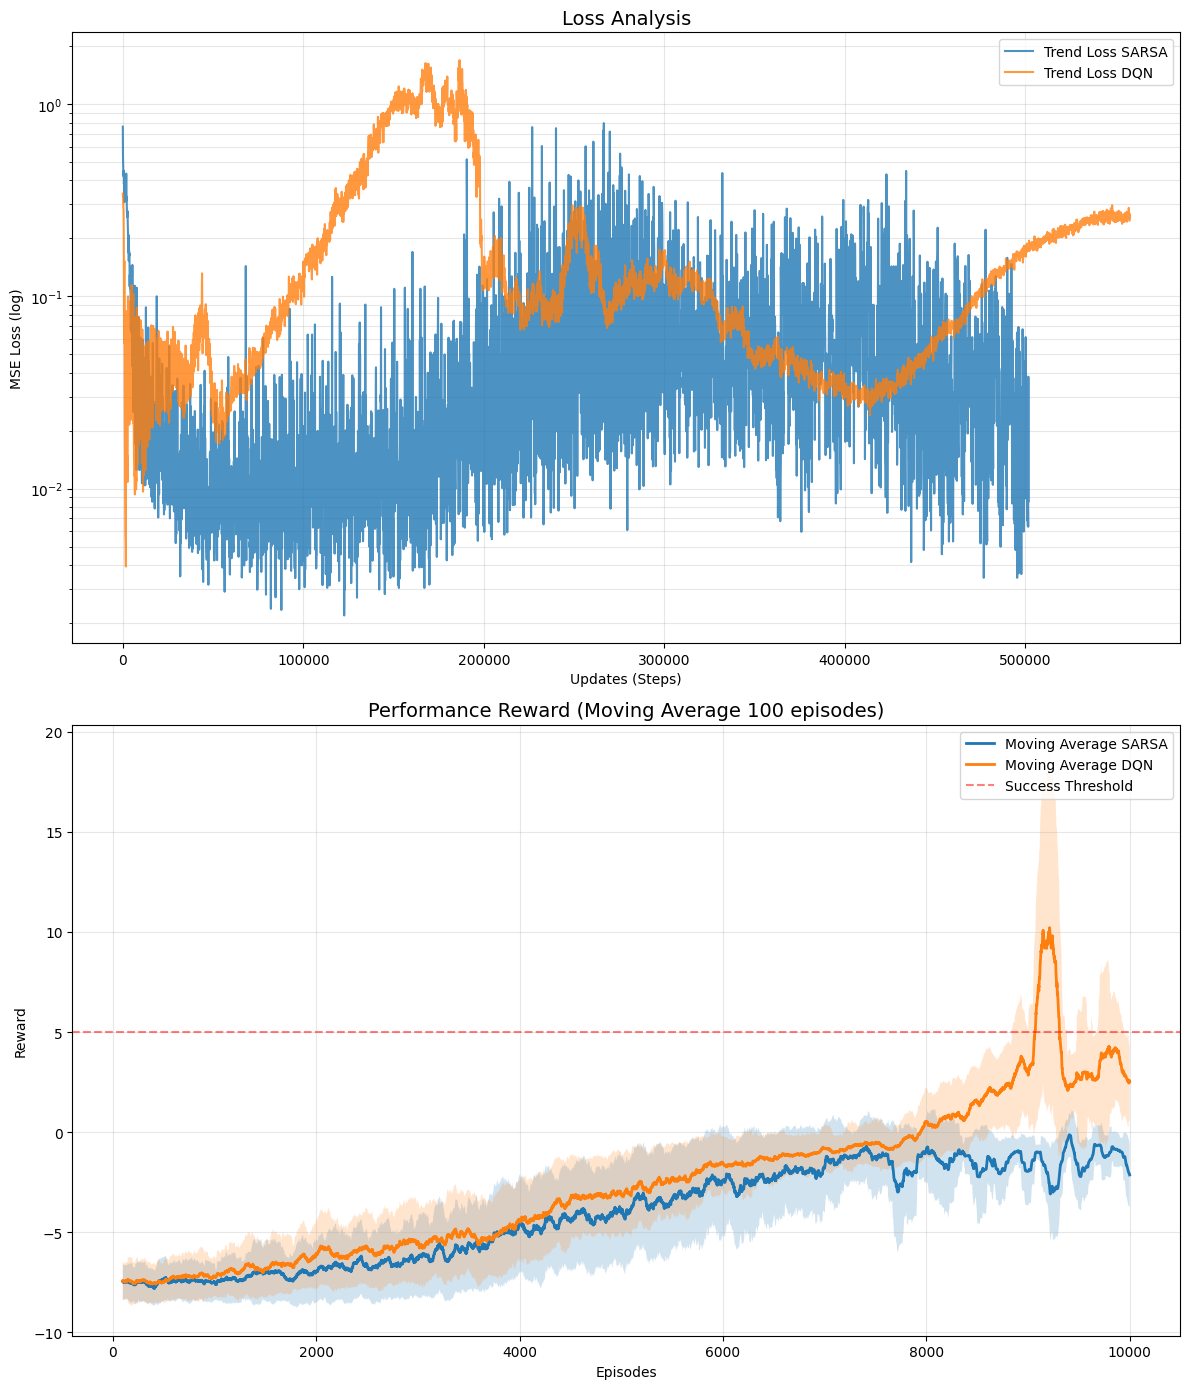

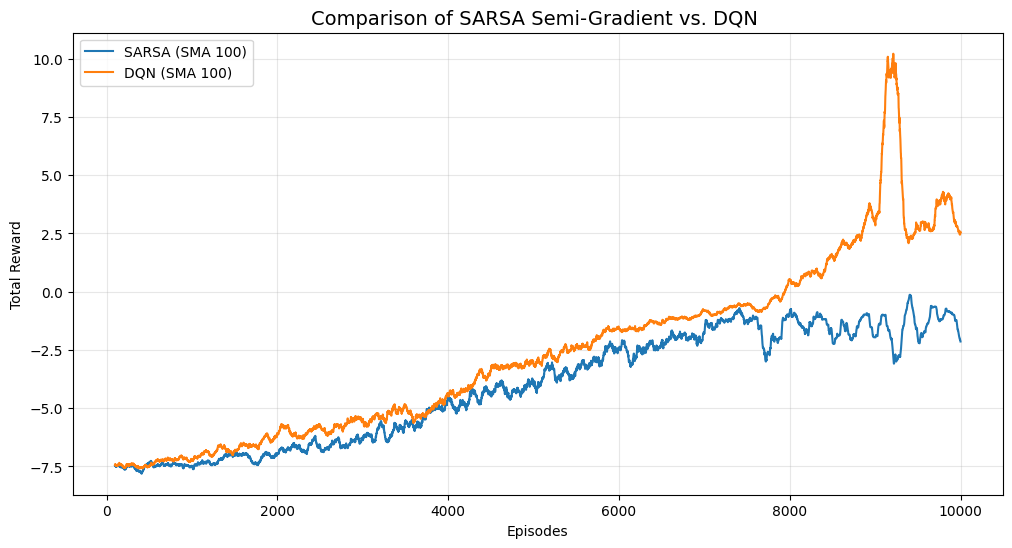

In [ ]:
# Genera tutto
for n in n_episodes:
    print(f"\n--- Analysis of results for {n} episodes --- \n")
    df_report = analyze_performance(results[n], agents[n])
    print(df_report)

    plot_advanced_analysis_apx(results[n], agents[n])
    # Visualizzazione del confronto
    plot_results_apx(results[n], "Comparison of SARSA Semi-Gradient vs. DQN ")
    

#### Test final (50 episodios, epsilon=0, modo greedy)

In [ ]:
# Creiamo un dizionario con gli agenti addestrati
for n in n_episodes:
    
    trained_agents = {
        "SARSA": agents[n]['SARSA'],
        "DQN": agents[n]['DQN']
    }

    print(f"\n--- Testing agents trained for {n} episodes ---")
    # Eseguiamo il test
    df_results = test_agents(trained_agents, "FlappyBird-v0",device, test_episodes=50)

    # Mostriamo la tabella
print("\n--- Final Test Results ---")
df_results


--- Testing agents trained for 10000 episodes ---
Testing SARSA over 50 episodes...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Testing DQN over 50 episodes...

--- Final Test Results ---


,Algoritmo,Recompensa media,Desviación estándar,Max Recompensa,Min Recompensa
0,SARSA,-0.900,0.000000,-0.9,-0.9
1,DQN,-3.456,6.703646,10.8,-9.3


### Registro de pruebas de juego

In [ ]:
for i in range(3):
    for n in n_episodes:
        record_agent_video(agents[n]['DQN'], "FlappyBird-v0", device, prefix=f"DQN_Flappy_{n}_episodes_{i}")
        record_agent_video(agents[n]['SARSA'], "FlappyBird-v0", device, prefix=f"SARSA_Flappy_{n}_episodes_{i}")

Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986
Video recorded! Total reward obtained: -0.8999999999999986


In [ ]:
def run_grid_search(agent_class,base_params, parameter_name, values_to_test, episodes=EPISODES):
    
    grid_results = {}
    
    for val in values_to_test:
        current_params = base_params.copy()
        current_params[parameter_name] = val 
        
        test_name = f"{parameter_name}={val}"
        print(f"\nStart Test: {agent_class.__name__} with {test_name}")
        
        grid_results[test_name] = run_experiment(agent_class,ENV, episodes=episodes, **current_params)
        
    return grid_results

## Estudio Learning Rate en Sarsa Semi-gradient

In [7]:
learning_rate = [1e-5, 1e-4, 1e-3]
sarsa_lr_results = run_grid_search(SARSASemiGradientAgent, params_SARSA, 'learning_rate', learning_rate)


Start Test: SARSASemiGradientAgent with learning_rate=1e-05


Training SARSASemiGradientAgent:  20%|██        | 2000/10000 [09:05<34:20,  3.88it/s]

Episode 2000/10000 | Epsilon: 0.780 | Avg last 100: -6.97


Training SARSASemiGradientAgent:  40%|████      | 4000/10000 [18:17<27:19,  3.66it/s]

Episode 4000/10000 | Epsilon: 0.560 | Avg last 100: -5.12


...

Episode 6000/10000 | Epsilon: 0.340 | Avg last 100: -2.86


Training SARSASemiGradientAgent:  80%|████████  | 8000/10000 [37:32<09:08,  3.64it/s]

Episode 8000/10000 | Epsilon: 0.120 | Avg last 100: -1.47


Training SARSASemiGradientAgent: 100%|██████████| 10000/10000 [47:15<00:00,  3.53it/s]

Episode 10000/10000 | Epsilon: 0.010 | Avg last 100: -6.22


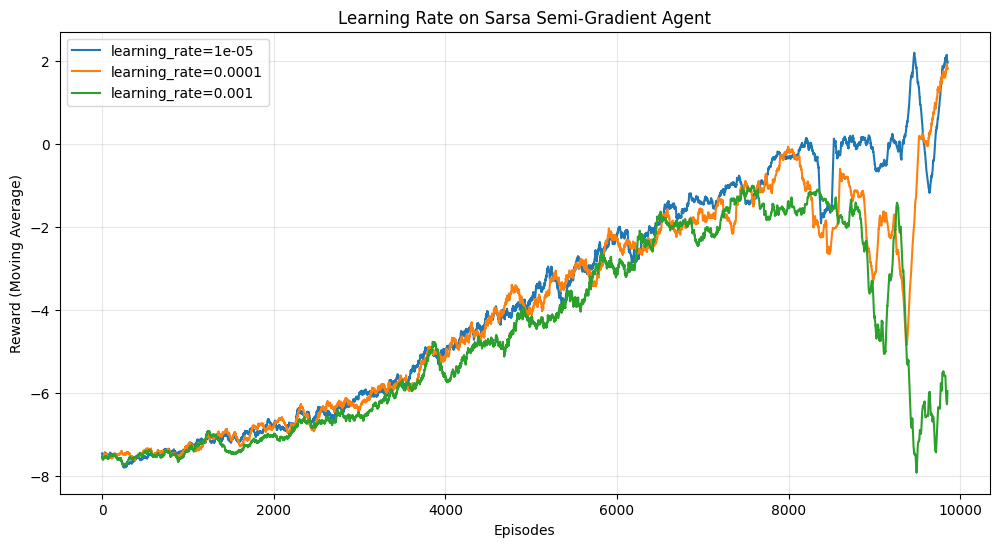

Memory cleared, experiments completed!


In [ ]:
plt.figure(figsize=(12, 6))

for label, (rewards, agent) in sarsa_lr_results.items():

    window = 150
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(ma, label=label)

plt.title("Learning Rate on Sarsa Semi-Gradient Agent")
plt.xlabel("Episodes")
plt.ylabel("Reward (Moving Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cleanup()
print("Memory cleared, experiments completed!")

## Estudio Learning Rate en DQN

In [6]:
learning_rate = [1e-5, 1e-4, 1e-3]
dqn_lr_results = run_grid_search(DQNAgent, params_DQN, 'learning_rate', learning_rate)


Start Test: DQNAgent with learning_rate=1e-05



Training DQNAgent:   0%|          | 0/10000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
Training DQNAgent:  20%|██        | 2000/10000 [10:50<42:33,  3.13it/s]

Episode 2000/10000 | Epsilon: 0.780 | Avg last 100: -6.28


Training DQNAgent:  40%|████      | 4000/10000 [22:11<33:40,  2.97it/s]

Episode 4000/10000 | Epsilon: 0.560 | Avg last 100: -3.77


...

Episode 6000/10000 | Epsilon: 0.340 | Avg last 100: -1.52


Training DQNAgent:  80%|████████  | 8000/10000 [45:14<11:42,  2.85it/s]

Episode 8000/10000 | Epsilon: 0.120 | Avg last 100: -0.68


Training DQNAgent: 100%|██████████| 10000/10000 [1:01:09<00:00,  2.72it/s]

Episode 10000/10000 | Epsilon: 0.010 | Avg last 100: 0.64


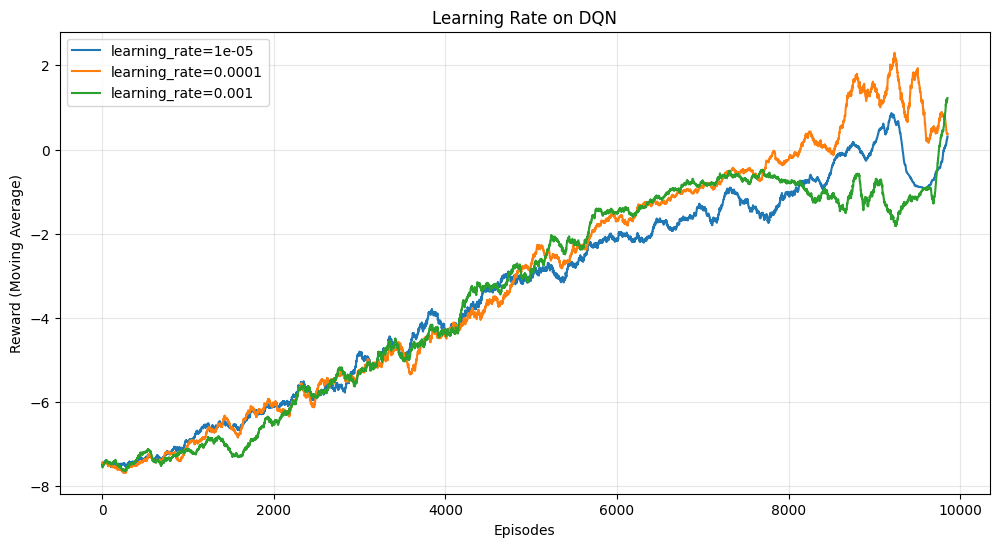

Memory cleared, experiments completed!


In [ ]:
plt.figure(figsize=(12, 6))

for label, (rewards, agent) in dqn_lr_results.items():

    window = 150
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(ma, label=label)

plt.title("Learning Rate on DQN")
plt.xlabel("Episodes")
plt.ylabel("Reward (Moving Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cleanup()
print("Memory cleared, experiments completed!")

## Estudio Target Update Frequency en DQN

In [27]:
target_update_values = [500,1000,2000]
dqn_tu_results = run_grid_search(DQNAgent, params_DQN, 'target_update_frequency', target_update_values)


Start Test: DQNAgent with target_update_frequency=500


Training DQNAgent:   5%|▌         | 500/10000 [01:59<37:17,  4.25it/s]  

Episode 500/10000 | Epsilon: 0.945 | Avg last 100: -7.33


Training DQNAgent:  10%|█         | 1000/10000 [03:59<36:01,  4.16it/s]

Episode 1000/10000 | Epsilon: 0.890 | Avg last 100: -7.16


...

Episode 9000/10000 | Epsilon: 0.010 | Avg last 100: 3.65


Training DQNAgent:  95%|█████████▌| 9500/10000 [45:15<03:05,  2.69it/s]

Episode 9500/10000 | Epsilon: 0.010 | Avg last 100: 2.83


Training DQNAgent: 100%|██████████| 10000/10000 [49:11<00:00,  3.39it/s]

Episode 10000/10000 | Epsilon: 0.010 | Avg last 100: 3.65


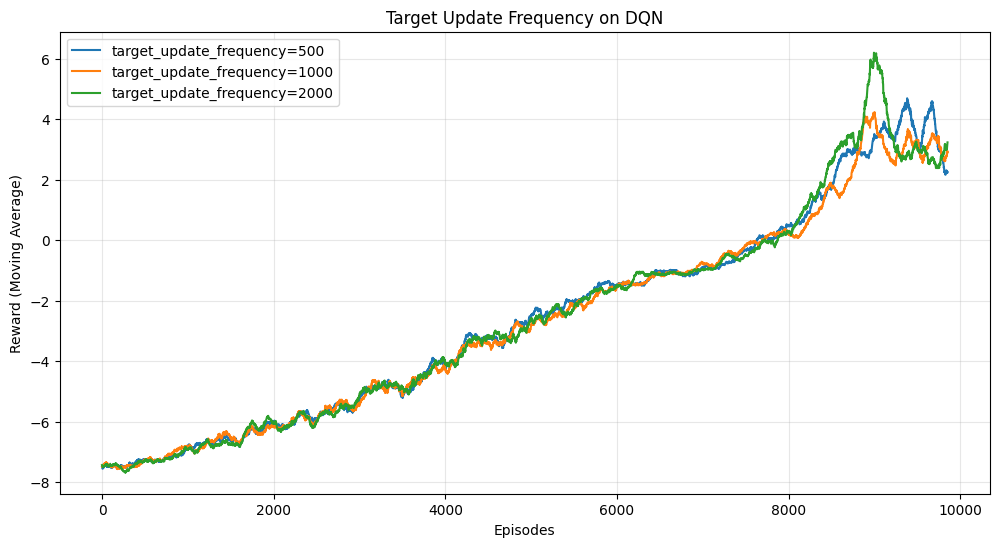

In [ ]:
plt.figure(figsize=(12, 6))

for label, (rewards, agent) in dqn_tu_results.items():
    
    window = 150
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(ma, label=label)

plt.title("Target Update Frequency on DQN")
plt.xlabel("Episodes")
plt.ylabel("Reward (Moving Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

cleanup()
print("Memory cleared, experiments completed!")

## Estudio Memory Size (Experience Replay) en DQN

In [12]:
memory = [50000, 100000, 200000]
dqn_memory_results = run_grid_search(DQNAgent, params_DQN, 'memory_size', memory)


Start Test: DQNAgent with memory_size=50000


Training DQNAgent:   5%|▌         | 500/10000 [01:57<37:46,  4.19it/s]

Episode 500/10000 | Epsilon: 0.945 | Avg last 100: -7.40


Training DQNAgent:  10%|█         | 1000/10000 [03:59<35:38,  4.21it/s] 

Episode 1000/10000 | Epsilon: 0.890 | Avg last 100: -6.97


...

Episode 9000/10000 | Epsilon: 0.010 | Avg last 100: 1.10


Training DQNAgent:  95%|█████████▌| 9500/10000 [46:39<05:05,  1.64it/s]

Episode 9500/10000 | Epsilon: 0.010 | Avg last 100: 5.38


Training DQNAgent: 100%|██████████| 10000/10000 [52:03<00:00,  3.20it/s]

Episode 10000/10000 | Epsilon: 0.010 | Avg last 100: 4.91


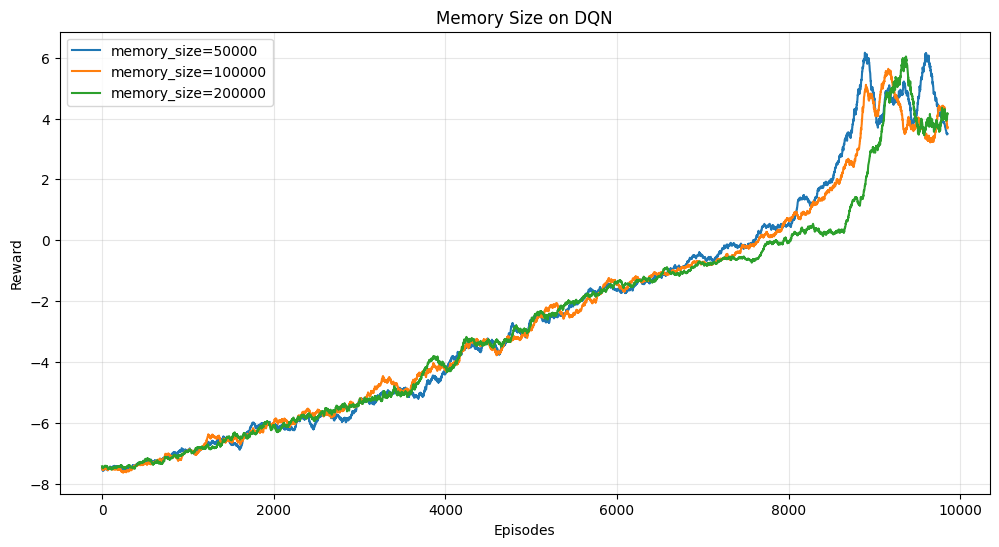

In [ ]:
plt.figure(figsize=(12, 6))

for label, (rewards, agent) in dqn_memory_results.items():
    
    window = 150
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(ma, label=label)

plt.title("Memory Size on DQN")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
cleanup()
print("Memory cleared, experiments completed!")

Memory cleared, experiments completed!
